# Private SpiderBoost against DP-SGD, on Criteo

dimma ships two private algorithms and has never run one against the other.
Notebook 01 ran DP-SGD alone; notebook 02 put DP-SGD against non-private SGD
and so measured what privacy costs — not what *choosing between two private
methods* costs. This notebook makes that comparison: **Private SpiderBoost
against DP-SGD**, both private, both calibrated to the same (ε, δ) over the
same number of steps by the same accountant, each tuned by the same rule on
the same validation split, and reported in the same metrics.

**On the numbering.** `03` is taken: the feature-norm-cost notebook exists as
notebook 03 on an unmerged branch — it is the evidence that closed #9 — and
`04` is claimed by another worktree for the projected-DP-SGD notebook. Neither
is a gap in the sequence and neither is this notebook's to renumber, so this
one is **05**. Notebook 02 set that precedent when it took the number the plan
had reserved for a different comparison and said so in its opening cell.

**The protocol is notebook 02's, fixed before anything is fitted.** The method
is inherited; none of the numbers are — notebook 02's closing section is
flagged *stale until re-run*, and no figure and no figure of merit is carried
over here:

- target **ε = 3, δ = 1e-6**, over **10,000 optimizer steps** at the full run;
- the enforced feature-norm bound **R = 2.0**, identical on both arms;
- the same Criteo load — all 39 features, preprocessed, standardized,
  `seed=0`, on GPU, the full file — and the same deterministic
  **700,000 / 100,000** train/validation cut of the training split;
- the **same initialization key for every run in both arms**; only the
  sampling and the noise streams move per run;
- **15 equal-mass bins**; selection on **lowest validation log-loss**,
  nan-safe, the identical rule on both sides;
- the test split untouched until the operating-point section;
- reported metrics: log-loss, PR-AUC against the base rate as its floor, ECE,
  normalized entropy, calibration ratio, the reliability curve, the log-loss
  decomposition, and a confusion matrix at the validation-F1 threshold chosen
  **per model**. **No ROC-AUC, no accuracy** (ADR-0016).

Every metric below is imported from `dimma.metrics`, and every training loop
from `dimma.algorithms`. This notebook computes no metric of its own and
reimplements no loop; what it owns is the plotting and the prose.

**The two epsilons are not the same kind of claim.** DP-SGD's sensitivity is
*enforced* by an operation — the per-sample clip to `C`. Private SpiderBoost's
is *assumed*: Algorithm 2 has no clipping line and dimma adds none (ADR-0009),
so its guarantee holds only if the shipped per-sample BCE really is
`L0`-Lipschitz and `L1`-smooth with the constants its noise was calibrated
against. Two identical ε columns below are not two identical guarantees, and
nothing in this notebook or in the library checks the second one.

> ### The run this file carries
>
> **The outputs stored here are the full configuration**, `SMOKE = False`:
> 10,000 optimizer steps per run, 60 runs in the DP-SGD grid and 54 in
> Private SpiderBoost's, the trajectory at six step counts, three seed
> repeats per arm, both calibrations at
> **ε = 3, δ = 1e-6** by RDP over exactly the steps that ran. Every number
> below is read off this execution, and the closing section is written against
> it.
>
> The configuration block carries a `SMOKE` switch beside it, which shortens
> the step count, the two grids and the trajectory schedule — and nothing
> else — so that the whole path can be exercised cheaply after an edit. It is
> a development convenience; it is not what this file was run with.

### The library this notebook ran against

Printed rather than assumed. `dimma.metrics.ranking` and
`dimma.metrics.operating_point` are the modules the ticket promoted out of the
notebooks; a checkout without them has nothing to fall back on, because there
is no local copy of either here.

In [1]:
import math
import time
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import dimma
from dimma.accounting import spiderboost as spiderboost_accounting
from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo
from dimma.metrics import operating_point, ranking
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
    reliability_curve,
)
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.operating_point import best_f1_threshold, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss

print("dimma:", dimma.__file__)
assert hasattr(ranking, "pr_curve"), "this checkout predates dimma.metrics.ranking"
assert hasattr(operating_point, "best_f1_threshold"), (
    "this checkout predates dimma.metrics.operating_point")
print("dimma.metrics.ranking and dimma.metrics.operating_point: present")

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

dimma: /home/diegol/dimma_lib/.claude/worktrees/spiderboost-vs-dp-sgd/src/dimma/__init__.py
dimma.metrics.ranking and dimma.metrics.operating_point: present


jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


### The configuration block

One block, two settings. `SMOKE` switches the step count, the two grids and
the trajectory schedule; **everything else — the budget, `R`, the bin count,
the seeds, the selection rule, the metrics — is the protocol and does not
move.** The full configuration is the one the opening cell describes: 10,000
steps, 60 runs in the DP-SGD grid and 54 in Private SpiderBoost's, a six-point
trajectory.

The grids are deliberately of comparable size and deliberately not of the same
shape. Section 4 says why, and says what each axis has to show before its
winner can be read as a winner.

In [2]:
SMOKE = False

# ---- the protocol. Identical in both configurations. --------------------
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6
FEATURE_NORM_BOUND = 2.0        # ADR-0012's R, fixed a priori, both arms
ACCOUNTANT = "rdp"              # ADR-0011, held fixed across the arms
N_BINS = 15                     # equal-mass bins, as notebooks 01 and 02
INIT_SEED = 0                   # the one initialization, every run, both arms
BASE_SEED = 20260819            # the sampling and noise streams move off this
SEEDS = (0, 1, 2)               # the repeat spread in the last section
PADDING_MARGIN_SIGMAS = 8.0     # ADR-0007; see the padding-cap note below

# ---- what SMOKE moves, and all it moves. --------------------------------
if SMOKE:
    STEPS = 200
    DP_LR_GRID = [0.3, 1.0]
    DP_CLIP_GRID = [0.3]
    DP_BATCH_GRID = [1024]
    SB_STEP_SCALE_GRID = [1.0, 0.25]      # multiples of the paper's 1/(2 L1)
    SB_ANCHOR_INTERVAL_GRID = [8]
    SB_BATCH_GRID = [(4096, 1024)]        # (b1, b2)
    TRAJECTORY_STEPS = [50, 100, 200]
else:
    STEPS = 10_000
    # Every axis carries at least three points, so "the winner is interior"
    # is a statement each of them can make. Both descent axes run past the
    # point where their arm gives up: at C = 10 an update is lr * C, so
    # lr = 30 moves the parameters 300 per step, and 256 * the paper's step
    # size is far outside any stability limit L1 implies. The weak ends are
    # kept sparse but present, because where an arm is bad is part of what
    # the grid measured.
    DP_LR_GRID = [0.3, 1.0, 3.0, 10.0, 30.0]
    DP_CLIP_GRID = [0.3, 1.0, 3.0, 10.0]
    DP_BATCH_GRID = [64, 256, 1024]
    SB_STEP_SCALE_GRID = [0.25, 1.0, 4.0, 16.0, 64.0, 256.0]
    SB_ANCHOR_INTERVAL_GRID = [8, 32, 128]
    SB_BATCH_GRID = [(2048, 512), (8192, 2048), (16384, 4096)]
    TRAJECTORY_STEPS = [250, 500, 1000, 2500, 5000, STEPS]

# A PLD number is a footnote and is reported for both arms or not at all
# (ADR-0011). It is not worth the wall-clock on a smoke run.
REPORT_PLD_FOOTNOTE = not SMOKE

DP_GRID_SIZE = len(DP_LR_GRID) * len(DP_CLIP_GRID) * len(DP_BATCH_GRID)
SB_GRID_SIZE = (len(SB_STEP_SCALE_GRID) * len(SB_ANCHOR_INTERVAL_GRID)
                * len(SB_BATCH_GRID))
print(f"SMOKE = {SMOKE}")
print(f"  steps per run        : {STEPS:,}")
print(f"  DP-SGD grid          : {DP_GRID_SIZE} runs")
print(f"  Private SpiderBoost  : {SB_GRID_SIZE} runs")
print(f"  trajectory points    : {TRAJECTORY_STEPS}")
print(f"  seed repeats         : {SEEDS}")
print(f"  budget               : epsilon = {TARGET_EPSILON:g}, "
      f"delta = {TARGET_DELTA}, method '{ACCOUNTANT}', over exactly "
      f"{STEPS:,} steps")

SMOKE = False
  steps per run        : 10,000
  DP-SGD grid          : 60 runs
  Private SpiderBoost  : 54 runs
  trajectory points    : [250, 500, 1000, 2500, 5000, 10000]
  seed repeats         : (0, 1, 2)
  budget               : epsilon = 3, delta = 1e-06, method 'rdp', over exactly 10,000 steps


### Chart styling

One palette block, so every figure reads as the same system. The two series
colours are categorical slots 1 and 2 of the reference palette, which clear
the colour-vision-deficiency and normal-vision separation floors against a
white surface. **Hue never carries a series on its own**: every series is in a
legend, and where two series share a panel they differ in line style and
marker as well.

In [3]:
ARMS = ("DP-SGD", "Private SpiderBoost")
SERIES = {"DP-SGD": "#2a78d6", "Private SpiderBoost": "#eb6834"}  # slots 1, 2
DASH = {"DP-SGD": "-", "Private SpiderBoost": "--"}
MARKER = {"DP-SGD": "o", "Private SpiderBoost": "s"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

## 1. The data, and the split both arms are selected on

`load_criteo` is the only thing here that touches the dataset, and it records
what it did in `metadata["preprocessing"]` so a run carries its own provenance
(ADR-0008). The call is notebook 02's, verbatim: all 39 features, the
preprocessing chain, standardized (ADR-0013 — an axis, asked for here rather
than inherited), the deterministic `seed=0` / `test_fraction=0.2` split, on
GPU, from the cached full file, with `feature_norm_bound = R = 2.0` enforced.

The 800,000-row training split is then cut once, deterministically, into
**700,000 train / 100,000 validation**. Both arms train on the same 700,000
rows and are selected on the same 100,000. The consequence for both
accountants is that **n = 700,000**, so every sampling rate below is
`b / 700_000`.

The test split is not read until the operating-point section.

In [4]:
split = load_criteo(features="all", preprocess=True, standardize=True,
                    download=False, seed=0,
                    device=DEVICE,
                    feature_norm_bound=FEATURE_NORM_BOUND)

n_all, n_features = split.x_train.shape

# One deterministic cut of the training split. Not a resample: a permutation
# with a fixed seed, held out once and never re-drawn.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:100_000])
train_index = jnp.asarray(holdout[100_000:])

X_TRAIN, Y_TRAIN = split.x_train[train_index], split.y_train[train_index]
X_VAL, Y_VAL = split.x_train[val_index], split.y_train[val_index]
# Bound here so the loader's arrays can be released below, and not read
# until section 7 — not even for its base rate.
X_TEST, Y_TEST = split.x_test, split.y_test

n_train = X_TRAIN.shape[0]
Y_VAL_NP = np.asarray(Y_VAL, dtype=np.float64)
VAL_BASE_RATE = float(Y_VAL_NP.mean())

print(f"train {X_TRAIN.shape}   val {X_VAL.shape}   test {X_TEST.shape} "
      f"(test bound, unread)")
print(f"label base rate: {float(Y_TRAIN.mean()):.4f} train, "
      f"{VAL_BASE_RATE:.4f} val")
print(f"validation PR-AUC floor (a random ranking scores the base rate): "
      f"{VAL_BASE_RATE:.4f}")
print(f"arrays live on: {list(X_TRAIN.devices())}")
print()
print(f"enforced feature norm bound R = {split.metadata['feature_norm_bound']}")
print()
print(split.metadata["preprocessing"])

# The loader's own train arrays are the largest objects on the device and
# nothing below reads them again — the six arrays above are gathers, not
# views, and `X_TEST` holds the test buffer itself. Dropped so the run's
# device footprint is what the run uses; this GPU is shared.
del split, holdout, train_index, val_index

criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


train (700000, 39)   val (100000, 39)   test (200000, 39) (test bound, unread)
label base rate: 0.2513 train, 0.2489 val
validation PR-AUC floor (a random ranking scores the base rate): 0.2489
arrays live on: [CudaDevice(id=0)]

enforced feature norm bound R = 2.0

39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


### `R` is load-bearing on one side only

Said once, here, because it is the asymmetry every number below inherits.

**DP-SGD's budget never sees `R`.** Its sensitivity is the clipping norm by
construction — every per-sample gradient is scaled to `‖g‖ ≤ C` before it is
summed, so `S = C`, the noise is `σ·C`, and the multiplier the accountant
returns is the same at every `C`. `R` changes the data DP-SGD trains on, and
so the model, but it does not enter its ε at all.

**For Private SpiderBoost `R` *is* the budget.** There is no clipping line
(ADR-0009). The sensitivity bounds come from the assumption that the loss is
`L0`-Lipschitz and `L1`-smooth, and for the shipped logistic regression under
the shipped per-sample BCE those constants are the largest augmented feature
norm and its square over four — functions of `R` and of the bias flag alone
(ADR-0012). So `R` fixes both constants and therefore all three noise scales,
and a run at a different `R` is a different mechanism at the same nominal ε.

That is why `R` has to be *identical* across the arms rather than merely
reasonable on each, and why it is fixed before the data is looked at: an `R`
read off the norms is a fitted `L0`, and an ε calibrated from a fitted `L0` is
false with no crash.

### The caveats that travel with every ε below

Three accesses sit outside every budget in this notebook (ADR-0008):

1. **The preprocessing statistics** — medians, category frequencies, means and
   standard deviations — are fitted on the training split and accounted for in
   no budget. The validation rows were inside the split they were fitted on,
   which is a second, smaller version of the same leak.
2. **The hyperparameter search is never accounted.** Both sweeps below train
   models and read validation loss off each one; the reported ε covers the
   single selected run per arm.
3. **Evaluating on held-out data is outside the loop by design.** Neither
   `train` returns metrics, precisely so the loop is not in a position to leak
   one.

And one that is particular to the private arm: **its guarantee is conditional
on an assumption nothing checks** (ADR-0009), whose premise is the `R` above.
`cap_feature_norms` warns — existence only, never a count — when a row's norm
is non-finite, because for that row the bound is believed rather than
enforced. Warnings are not suppressed anywhere in this notebook.

## 2. Shared machinery: one evaluator, one runner per arm

Everything that could differ between the arms by accident is written once
here. Both arms start from the same parameters, descend with the same
optimizer object (ADR-0002), take the same number of steps, and are scored by
the same `evaluate_at`, which squashes the logits once and hands
probabilities to `dimma.metrics`.

Nothing in this cell computes a metric. `log_loss`,
`expected_calibration_error` and `pr_curve` are imported; what the notebook
owns is the single conversion from logits to probabilities and the divergence
guard in front of them — the metrics raise on non-finite input rather than
returning `nan`, so a diverged run has to be given no score at all rather than
a bad one.

In [5]:
class Eval(NamedTuple):
    # What one run is scored on, on whichever split it was pointed at. All
    # three are threshold-free; the operating point arrives in section 7 and
    # nothing here depends on it.
    loss: float
    pr_auc: float
    ece: float


def scores(params, x):
    # Logits for a whole array. `forward` is a single-example function.
    return np.asarray(jax.vmap(forward, in_axes=(None, 0))(params, x))


def probabilities(logits):
    # The logits squashed once, so every number below reads one array.
    return np.asarray(jax.nn.sigmoid(jnp.asarray(logits)), dtype=np.float64)


def evaluate_at(params, x, y):
    # Score one parameter set on an arbitrary split. Guards divergence.
    if params is None:
        return Eval(float("nan"), float("nan"), float("nan"))
    logits = scores(params, x)
    if not np.all(np.isfinite(logits)):
        return Eval(float("nan"), float("nan"), float("nan"))
    probs, labels = probabilities(logits), np.asarray(y, dtype=np.float64)
    return Eval(loss=log_loss(probs, labels),
                pr_auc=pr_curve(probs, labels).average_precision,
                ece=expected_calibration_error(probs, labels, n_bins=N_BINS))


def show_confusion(confusion, title, threshold):
    # The 2x2 as a table — four numbers do not need a chart.
    tn, fp, fn, tp = confusion
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {tn:>12,}    {fp:>15,}")
    print(f"  actual click   {fn:>12,}    {tp:>15,}")
    precision = tp / (tp + fp) if tp + fp else float("nan")
    recall = tp / (tp + fn) if tp + fn else float("nan")
    print(f"  precision {precision:.4f}   TPR (recall) {recall:.4f}   "
          f"(at threshold p >= {threshold:.4f})")

### The two runners, the key discipline, and the padding caps

**The key discipline is notebook 02's.** The initialization is
`init_params(jax.random.key(INIT_SEED), d)` for **every run in both arms** —
one starting point, not one per arm and not one per configuration. What moves
per run is the sampling stream, `numpy.random.default_rng([BASE_SEED, i])`,
and the noise stream, `jax.random.key(BASE_SEED + i)`, both folded off a
`seed_index` that is the run's position in the grid, so the whole sweep
reproduces from the notebook alone.

**The padding caps are chosen, not defaulted.** A Poisson draw has
data-dependent cardinality, so each branch pads to a cap and an oversize draw
**raises** — truncating would make inclusion dependent across examples and
void the amplification the accountant assumes (ADR-0007). The library's
default margin is 6 sigmas, at roughly 1e-9 per draw; over 10,000 draws *per
branch*, with three branches in flight across the two arms, that is a run that
can die near its end for no scientific reason. So the margin is raised to
**8 sigmas**, and the caps are computed **separately for the two SpiderBoost
branches** — the anchor batch is several times the variation batch, and one
cap for both would spend an `O(b1)` batch on every variation step. The DP-SGD
lot gets its cap on the same rule, so the arms differ in their mechanism and
not in their memory margin. If a run raises, the cap goes up and the run is
repeated; the exception is never caught.

In [6]:
def cap_for(expected_batch_size):
    # This run's padding cap for one branch. Not a privacy parameter.
    return poisson.padded_batch_size(expected_batch_size, n_train,
                                     margin_sigmas=PADDING_MARGIN_SIGMAS)


def fresh_params():
    # The one starting point, shared by both arms and every configuration.
    return init_params(jax.random.key(INIT_SEED), n_features)


def noise_key(seed_index):
    return jax.random.key(BASE_SEED + seed_index)


def sampling_rng(seed_index):
    return np.random.default_rng([BASE_SEED, seed_index])


def fit_dp_sgd(*, learning_rate, expected_batch_size, clip_norm,
               noise_multiplier, steps=STEPS, seed_index=0):
    # DP-SGD: Poisson lots, per-sample clipping to `clip_norm`, then noise.
    return dp_sgd.train(
        per_sample_bce_loss, fresh_params(), updates.sgd(learning_rate),
        X_TRAIN, Y_TRAIN, noise_key(seed_index), sampling_rng(seed_index),
        steps=steps, expected_batch_size=expected_batch_size,
        clip_norm=clip_norm, noise_multiplier=noise_multiplier,
        b_max=cap_for(expected_batch_size),
    )


def fit_spiderboost(*, step_size, anchor_interval, b1, b2, scales,
                    steps=STEPS, seed_index=0):
    # Private SpiderBoost. Returns (output-rule iterate, last iterate).
    return spiderboost.train(
        per_sample_bce_loss, fresh_params(), updates.sgd(step_size),
        X_TRAIN, Y_TRAIN, noise_key(seed_index), sampling_rng(seed_index),
        steps=steps, anchor_interval=anchor_interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        anchor_b_max=cap_for(b1), variation_b_max=cap_for(b2),
    )


print(f"padding caps at {PADDING_MARGIN_SIGMAS:g} sigmas, n = {n_train:,}")
for name, sizes in (
        ("DP-SGD lot L", DP_BATCH_GRID),
        ("SpiderBoost anchor b1", [b1 for b1, _ in SB_BATCH_GRID]),
        ("SpiderBoost variation b2", [b2 for _, b2 in SB_BATCH_GRID])):
    caps = ",  ".join(f"{b} -> {cap_for(b)}" for b in sorted(set(sizes)))
    print(f"  {name:<26} {caps}")

padding caps at 8 sigmas, n = 700,000
  DP-SGD lot L               64 -> 132,  256 -> 388,  1024 -> 1284
  SpiderBoost anchor b1      2048 -> 2414,  8192 -> 8916,  16384 -> 17400
  SpiderBoost variation b2   512 -> 697,  2048 -> 2414,  4096 -> 4611


## 3. Two budgets, one accountant

Both arms are calibrated to the **same (ε, δ)**, over **exactly the step count
that runs**, by the **same method** — RDP, `dimma.accounting`'s default and
ADR-0011's decision, held fixed here because that is the property which makes
two epsilons comparable quantities rather than two numbers.

The two calibrations are not the same calculation, and the difference is the
point of this notebook.

**DP-SGD** releases on one schedule: `steps` Poisson-subsampled Gaussian
releases at rate `q = L / n`. The clipping norm does not appear — sensitivity
is `S = C` by construction and the noise is `σ·C`, so the multiplier is the
same at every `C` and `C` is free as far as the budget is concerned. `R` does
not appear either, for the reason section 1 gives. What does appear is `L`, so
the sweep needs one multiplier per expected lot size.

**Private SpiderBoost** releases on *two* schedules —
`ceil(steps / anchor_interval)` anchor releases at rate `b1 / n` and the rest
variation releases at `b2 / n` — composed in one accountant rather than summed
(ADR-0010). Its scales come from the constants, not from the data: `L0` and
`L1` are `logreg_bce_constants(R, has_bias=...)` for the shipped logistic
regression under the shipped per-sample BCE, and the budget buys the shared
multiplier `μ` that turns into the three scales
`μ·L0/b1`, `μ·L1/b2` and `2·μ·L0/b2`. Those three go to `train` **unconverted**,
so no translation step between the accountant and the loop can silently
disagree with what ran.

**The bias flag is read off the shipped model, never defaulted.** The augmented
norm is `‖x‖² + 1` when the model carries a bias, which moves `L1`, the step
size and every noise scale; a wrong flag reports an ε that is simply false.

In [7]:
def dp_sigma_for(expected_batch_size, steps=STEPS, epsilon=TARGET_EPSILON):
    # The smallest noise multiplier meeting (epsilon, delta) for this shape.
    q = expected_batch_size / n_train
    return calibrate_noise_multiplier(
        lambda multiplier: [PoissonGaussianSchedule(q, multiplier, steps)],
        epsilon, TARGET_DELTA, method=ACCOUNTANT,
    )


SIGMA, DP_EPSILON_BACK = {}, {}

t0 = time.time()
for L in DP_BATCH_GRID:
    SIGMA[L] = dp_sigma_for(L)
    # The reporting direction, from the multiplier the run is handed.
    DP_EPSILON_BACK[L] = poisson_gaussian_epsilon(
        L / n_train, SIGMA[L], STEPS, TARGET_DELTA, method=ACCOUNTANT)
    assert DP_EPSILON_BACK[L] <= TARGET_EPSILON + 1e-9
    print(f"L={L:<6} q={L / n_train:.6f}  sigma={SIGMA[L]:.6f}"
          f"  ->  epsilon={DP_EPSILON_BACK[L]:.6f}")
print(f"\nDP-SGD calibrated in {time.time() - t0:.1f}s "
      f"(method={ACCOUNTANT!r}, delta={TARGET_DELTA}, {STEPS:,} steps)")
print("the clipping norm C is absent by construction: sensitivity is C, the "
      "noise is sigma*C, so the multiplier does not depend on it")

L=64     q=0.000091  sigma=0.520882  ->  epsilon=2.999989


L=256    q=0.000366  sigma=0.583168  ->  epsilon=2.999998


L=1024   q=0.001463  sigma=0.699134  ->  epsilon=2.999999

DP-SGD calibrated in 0.6s (method='rdp', delta=1e-06, 10,000 steps)
the clipping norm C is absent by construction: sensitivity is C, the noise is sigma*C, so the multiplier does not depend on it


In [8]:
# The bias flag comes off the shipped model rather than a default: the
# parameter pytree is {"w": (d,), "b": ()}, so this model carries a bias.
HAS_BIAS = "b" in fresh_params()
assert HAS_BIAS, "the shipped logreg carries a bias; a wrong flag is a false epsilon"

CONSTANTS = logreg_bce_constants(FEATURE_NORM_BOUND, has_bias=HAS_BIAS)
PAPER_STEP_SIZE = CONSTANTS.step_size

print(f"R = {FEATURE_NORM_BOUND}, has_bias = {HAS_BIAS}  (read off the model)")
print(f"  L0 = {CONSTANTS.lipschitz_constant:.6f}")
print(f"  L1 = {CONSTANTS.smoothness_constant:.6f}")
print(f"  Theorem B.3 step size 1/(2*L1) = {PAPER_STEP_SIZE:.6f}")
print()

SCALES, SB_EPSILON_BACK = {}, {}

t0 = time.time()
for b1, b2 in SB_BATCH_GRID:
    for interval in SB_ANCHOR_INTERVAL_GRID:
        anchors, variations = spiderboost_accounting.release_counts(
            STEPS, interval)
        scales = spiderboost_accounting.noise_scales(
            lipschitz_constant=CONSTANTS.lipschitz_constant,
            smoothness_constant=CONSTANTS.smoothness_constant,
            target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
            steps=STEPS, anchor_interval=interval,
            anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
            dataset_size=n_train, method=ACCOUNTANT,
        )
        # The reporting direction, from the three scales `train` is handed.
        spent = spiderboost_accounting.epsilon(
            lipschitz_constant=CONSTANTS.lipschitz_constant,
            smoothness_constant=CONSTANTS.smoothness_constant,
            anchor_noise_scale=scales.anchor_noise_scale,
            variation_noise_rate=scales.variation_noise_rate,
            variation_noise_cap=scales.variation_noise_cap,
            target_delta=TARGET_DELTA, steps=STEPS, anchor_interval=interval,
            anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
            dataset_size=n_train, method=ACCOUNTANT,
        )
        assert spent <= TARGET_EPSILON + 1e-9
        SCALES[(interval, b1, b2)] = scales
        SB_EPSILON_BACK[(interval, b1, b2)] = spent
        print(f"q_phase={interval:<4} b1={b1:<6} b2={b2:<6} "
              f"({anchors} anchor + {variations} variation releases)")
        print(f"    sigma_1={scales.anchor_noise_scale:.6e}   "
              f"sigma_2={scales.variation_noise_rate:.6e}   "
              f"sigma_2_cap={scales.variation_noise_cap:.6e}"
              f"  ->  epsilon={spent:.6f}")
print(f"\nPrivate SpiderBoost calibrated in {time.time() - t0:.1f}s "
      f"(method={ACCOUNTANT!r}, delta={TARGET_DELTA}, {STEPS:,} steps)")

R = 2.0, has_bias = True  (read off the model)
  L0 = 2.236068
  L1 = 1.250000
  Theorem B.3 step size 1/(2*L1) = 0.400000



q_phase=8    b1=2048   b2=512    (1250 anchor + 8750 variation releases)
    sigma_1=7.744523e-04   sigma_2=1.731728e-03   sigma_2_cap=6.195619e-03  ->  epsilon=2.999998


q_phase=32   b1=2048   b2=512    (313 anchor + 9687 variation releases)
    sigma_1=7.395873e-04   sigma_2=1.653768e-03   sigma_2_cap=5.916699e-03  ->  epsilon=2.999990


q_phase=128  b1=2048   b2=512    (79 anchor + 9921 variation releases)
    sigma_1=7.168431e-04   sigma_2=1.602910e-03   sigma_2_cap=5.734745e-03  ->  epsilon=2.999989


q_phase=8    b1=8192   b2=2048   (1250 anchor + 8750 variation releases)
    sigma_1=2.984008e-04   sigma_2=6.672446e-04   sigma_2_cap=2.387207e-03  ->  epsilon=2.999996


q_phase=32   b1=8192   b2=2048   (313 anchor + 9687 variation releases)
    sigma_1=2.546698e-04   sigma_2=5.694591e-04   sigma_2_cap=2.037359e-03  ->  epsilon=2.999999


q_phase=128  b1=8192   b2=2048   (79 anchor + 9921 variation releases)
    sigma_1=2.397133e-04   sigma_2=5.360152e-04   sigma_2_cap=1.917706e-03  ->  epsilon=2.999992


q_phase=8    b1=16384  b2=4096   (1250 anchor + 8750 variation releases)
    sigma_1=2.468740e-04   sigma_2=5.520270e-04   sigma_2_cap=1.974992e-03  ->  epsilon=2.999998


q_phase=32   b1=16384  b2=4096   (313 anchor + 9687 variation releases)
    sigma_1=1.891418e-04   sigma_2=4.229339e-04   sigma_2_cap=1.513134e-03  ->  epsilon=2.999997


q_phase=128  b1=16384  b2=4096   (79 anchor + 9921 variation releases)
    sigma_1=1.702907e-04   sigma_2=3.807815e-04   sigma_2_cap=1.362325e-03  ->  epsilon=2.999996

Private SpiderBoost calibrated in 4.3s (method='rdp', delta=1e-06, 10,000 steps)


Both directions agree with their calibrations to floating point and land at
the target from below: the budget is met, not approached from above. The two
tables above are the *calibrating* direction; the summary below is the
**reporting** direction on both arms — ε recomputed from the scales the loops
are actually handed, so a calibration and a report cannot silently disagree.

In [9]:
print(f"epsilon at delta = {TARGET_DELTA}, method {ACCOUNTANT!r}, over "
      f"{STEPS:,} steps, computed back from the scales that run:\n")
print(f"  {'DP-SGD':<22}{'configuration':<26}{'from the scale':>16}")
for L in DP_BATCH_GRID:
    print(f"  {'':<22}{f'L={L}, sigma={SIGMA[L]:.4f}':<26}"
          f"{DP_EPSILON_BACK[L]:>16.6f}")
print()
print(f"  {'Private SpiderBoost':<22}{'configuration':<26}{'from the scales':>16}")
for (interval, b1, b2), spent in SB_EPSILON_BACK.items():
    print(f"  {'':<22}{f'q={interval}, b1={b1}, b2={b2}':<26}{spent:>16.6f}")
print(f"\nsame budget, same delta, same accountant, same step count on both "
      f"arms — the two epsilons are comparable quantities.")
print("They are not comparable guarantees: DP-SGD's sensitivity is enforced "
      "by the clip, Private SpiderBoost's is assumed (ADR-0009).")

epsilon at delta = 1e-06, method 'rdp', over 10,000 steps, computed back from the scales that run:

  DP-SGD                configuration               from the scale
                        L=64, sigma=0.5209                2.999989
                        L=256, sigma=0.5832               2.999998
                        L=1024, sigma=0.6991              2.999999

  Private SpiderBoost   configuration              from the scales
                        q=8, b1=2048, b2=512              2.999998
                        q=32, b1=2048, b2=512             2.999990
                        q=128, b1=2048, b2=512            2.999989
                        q=8, b1=8192, b2=2048             2.999996
                        q=32, b1=8192, b2=2048            2.999999
                        q=128, b1=8192, b2=2048           2.999992
                        q=8, b1=16384, b2=4096            2.999998
                        q=32, b1=16384, b2=4096           2.999997
                        q=12

**On PLD.** A PLD number would be smaller for the same run — at these sampling
rates and this budget, RDP asks for materially more noise (ADR-0011). It is
reported as a footnote, for **both** arms or for neither, and never as the
headline: what a comparison needs is one accountant held fixed across the
arms. The smoke configuration skips it, since a second calibration buys
nothing when the numbers are not results.

In [10]:
if REPORT_PLD_FOOTNOTE:
    L = DP_BATCH_GRID[-1]
    interval, b1, b2 = next(iter(SCALES))
    pld_sigma = calibrate_noise_multiplier(
        lambda m: [PoissonGaussianSchedule(L / n_train, m, STEPS)],
        TARGET_EPSILON, TARGET_DELTA, method="pld")
    pld_scales = spiderboost_accounting.noise_scales(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        steps=STEPS, anchor_interval=interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        dataset_size=n_train, method="pld")
    print("footnote, both arms, PLD instead of RDP at the same budget:")
    print(f"  DP-SGD  L={L}: sigma {SIGMA[L]:.6f} (rdp) vs "
          f"{pld_sigma:.6f} (pld)")
    print(f"  SpiderBoost q={interval}, b1={b1}, b2={b2}: sigma_1 "
          f"{SCALES[(interval, b1, b2)].anchor_noise_scale:.6e} (rdp) vs "
          f"{pld_scales.anchor_noise_scale:.6e} (pld)")
    print("Everything else in this notebook is RDP's.")
else:
    print("PLD footnote skipped: this is the smoke configuration "
          "(REPORT_PLD_FOOTNOTE = False). Every number here is RDP's.")

footnote, both arms, PLD instead of RDP at the same budget:
  DP-SGD  L=1024: sigma 0.699134 (rdp) vs 0.650610 (pld)
  SpiderBoost q=8, b1=2048, b2=512: sigma_1 7.744523e-04 (rdp) vs 7.159545e-04 (pld)
Everything else in this notebook is RDP's.


## 4. The grids, which are not the same shape

Both arms are swept, over grids of comparable size, and each keeps its own
best configuration: an untuned arm understates its algorithm, on either side.
The two grids are **not symmetric**, and the asymmetry is the algorithms', not
a choice about effort:

- **DP-SGD** sweeps **learning rate × clipping norm × expected lot size**. The
  clipping norm is the axis the other arm does not have, and it is the one
  that interacts with the learning rate — clipping to `C` caps the update at
  `lr·C`, so the useful configurations lie along a diagonal rather than at a
  point.
- **Private SpiderBoost has no clipping line at all** (ADR-0009), so there is
  no `C` to sweep. What it has instead is the **phase size** — `anchor_interval`,
  the paper's `q`, which decides how often the running estimate is re-anchored
  and so how the budget is split between the two branches — and **two**
  expected batch sizes, `b1` for the anchor branch and `b2` for the variation
  branch. So it sweeps **step size × phase size × (b1, b2)**.

**The step size is the one real design decision.** Theorem B.3 fixes it at
`1/(2·L1)`, and departing from it leaves the privacy intact but drops the
convergence guarantee *and* changes how far the parameters move per step,
which feeds the variation branch's noise — so it changes the mechanism, not
only what can be proved about it. The decision here is to **sweep it like any
other axis and mark the paper's value on the grid**: the grid is stated in
multiples of `1/(2·L1)`, so the paper's value is the entry at multiple 1. If
the selection lands somewhere else, both are reported below, with the headline
named and with what the other gives up.

`b1` and `b2` are named for their branches because transposing them silently
runs a different mechanism. Every run is `STEPS` steps — the same step budget
the reported models get, and the same one section 3 calibrated against.

**Every axis carries at least three points, and both descent axes run past the
point where their arm gives up.** That is what makes the phrase "the selected
configuration is interior to the grid" mean something: a winner sitting at the
end of an axis is a grid that stopped early, not an optimum, and it is
indistinguishable from one. So the learning rate runs to 30 and the clipping
norm to 10 — at that corner an update is `lr·C = 300`, which no loss surface
survives — and Private SpiderBoost's step size runs to 256 times the paper's
value. The rows that blow up are **kept in the tables**, whether they
come back as a large finite loss or as a `nan`: either way that is where the
grid found the arm's edge, and selection is nan-safe precisely so such rows
can stay. The weak low ends are kept sparse but present, for the same reason
in the other direction.

Each axis on which an earlier pass of these grids selected an end point is
extended outward here: DP-SGD's clipping norm and learning rate upward, its
lot size downward to 64, and Private SpiderBoost's phase size and batch pair
one step beyond. Which of them that bracketing worked on, and which it did
not, is read off the tables below rather than assumed.

**The selection rule, stated once and applied identically to both arms: the
lowest validation log-loss**, nan-safe, with the diverged rows kept in the
table rather than filtered, because the shape of where a grid breaks is part
of what the grid measured. PR-AUC is reported everywhere and selects nothing.

**Private SpiderBoost is scored on its output-rule iterate** here and
everywhere below — the iterate the convergence theorem bounds. Section 5 shows
the last iterate once, beside it, so the gap is visible.

In [11]:
dp_sweep = []
counter = 0
t0 = time.time()
for L in DP_BATCH_GRID:
    for clip in DP_CLIP_GRID:
        for lr in DP_LR_GRID:
            params = fit_dp_sgd(learning_rate=lr, expected_batch_size=L,
                                clip_norm=clip, noise_multiplier=SIGMA[L],
                                seed_index=counter)
            ev = evaluate_at(params, X_VAL, Y_VAL)
            dp_sweep.append(dict(lr=lr, clip=clip, batch=L, loss=ev.loss,
                                 pr_auc=ev.pr_auc, seed_index=counter))
            print(f"  L={L:<6} C={clip:<5} lr={lr:<7} "
                  f"val log-loss={ev.loss:.4f}  val PR-AUC={ev.pr_auc:.4f}")
            counter += 1
DP_SWEEP_SECONDS = time.time() - t0
print(f"\nDP-SGD sweep: {len(dp_sweep)} runs x {STEPS:,} steps in "
      f"{DP_SWEEP_SECONDS:.0f}s "
      f"({DP_SWEEP_SECONDS / len(dp_sweep):.1f}s per run, "
      f"{1e3 * DP_SWEEP_SECONDS / (len(dp_sweep) * STEPS):.2f}ms per step)")

  L=64     C=0.3   lr=0.3     val log-loss=0.7158  val PR-AUC=0.4425


  L=64     C=0.3   lr=1.0     val log-loss=0.7344  val PR-AUC=0.4458


  L=64     C=0.3   lr=3.0     val log-loss=0.7334  val PR-AUC=0.4464


  L=64     C=0.3   lr=10.0    val log-loss=0.7252  val PR-AUC=0.4377


  L=64     C=0.3   lr=30.0    val log-loss=0.7287  val PR-AUC=0.4254


...

  L=1024   C=10.0  lr=0.3     val log-loss=0.5069  val PR-AUC=0.4464


  L=1024   C=10.0  lr=1.0     val log-loss=0.5075  val PR-AUC=0.4429


  L=1024   C=10.0  lr=3.0     val log-loss=0.5082  val PR-AUC=0.4435


  L=1024   C=10.0  lr=10.0    val log-loss=0.5187  val PR-AUC=0.4355


  L=1024   C=10.0  lr=30.0    val log-loss=0.9775  val PR-AUC=0.4203

DP-SGD sweep: 60 runs x 10,000 steps in 4162s (69.4s per run, 6.94ms per step)


In [12]:
SB_SEED_OFFSET = 100   # a stream of its own; the initialization is unchanged

sb_sweep = []
counter = 0
t0 = time.time()
for b1, b2 in SB_BATCH_GRID:
    for interval in SB_ANCHOR_INTERVAL_GRID:
        for scale in SB_STEP_SCALE_GRID:
            eta = scale * PAPER_STEP_SIZE
            output_params, _ = fit_spiderboost(
                step_size=eta, anchor_interval=interval, b1=b1, b2=b2,
                scales=SCALES[(interval, b1, b2)],
                seed_index=SB_SEED_OFFSET + counter)
            ev = evaluate_at(output_params, X_VAL, Y_VAL)
            sb_sweep.append(dict(step_size=eta, step_scale=scale,
                                 interval=interval, b1=b1, b2=b2,
                                 loss=ev.loss, pr_auc=ev.pr_auc,
                                 seed_index=SB_SEED_OFFSET + counter))
            paper = "  <- Theorem B.3's 1/(2*L1)" if scale == 1.0 else ""
            print(f"  b1={b1:<6} b2={b2:<6} q={interval:<4} "
                  f"eta={eta:<8.4f} val log-loss={ev.loss:.4f}  "
                  f"val PR-AUC={ev.pr_auc:.4f}{paper}")
            counter += 1
SB_SWEEP_SECONDS = time.time() - t0
print(f"\nPrivate SpiderBoost sweep: {len(sb_sweep)} runs x {STEPS:,} steps "
      f"in {SB_SWEEP_SECONDS:.0f}s "
      f"({SB_SWEEP_SECONDS / len(sb_sweep):.1f}s per run, "
      f"{1e3 * SB_SWEEP_SECONDS / (len(sb_sweep) * STEPS):.2f}ms per step)")
print(f"\nwall-clock per step, SpiderBoost / DP-SGD: "
      f"{(SB_SWEEP_SECONDS / len(sb_sweep)) / (DP_SWEEP_SECONDS / len(dp_sweep)):.2f}x")
print("A variation step takes per-sample gradients at two parameter points, "
      "so it costs about twice a DP-SGD step before the anchor batches are "
      "counted; the measured ratio also carries the batch sizes each grid "
      "chose.")

  b1=2048   b2=512    q=8    eta=0.1000   val log-loss=0.5071  val PR-AUC=0.4436


  b1=2048   b2=512    q=8    eta=0.4000   val log-loss=0.5073  val PR-AUC=0.4439  <- Theorem B.3's 1/(2*L1)


  b1=2048   b2=512    q=8    eta=1.6000   val log-loss=0.5077  val PR-AUC=0.4451


  b1=2048   b2=512    q=8    eta=6.4000   val log-loss=0.5086  val PR-AUC=0.4416


  b1=2048   b2=512    q=8    eta=25.6000  val log-loss=1.2371  val PR-AUC=0.3058


...

  b1=16384  b2=4096   q=128  eta=0.4000   val log-loss=0.5070  val PR-AUC=0.4468  <- Theorem B.3's 1/(2*L1)


  b1=16384  b2=4096   q=128  eta=1.6000   val log-loss=0.5079  val PR-AUC=0.4456


  b1=16384  b2=4096   q=128  eta=6.4000   val log-loss=0.5073  val PR-AUC=0.4483


  b1=16384  b2=4096   q=128  eta=25.6000  val log-loss=1.1078  val PR-AUC=0.3269


  b1=16384  b2=4096   q=128  eta=102.4000 val log-loss=8.7639  val PR-AUC=0.2468

Private SpiderBoost sweep: 54 runs x 10,000 steps in 3939s (72.9s per run, 7.29ms per step)

wall-clock per step, SpiderBoost / DP-SGD: 1.05x
A variation step takes per-sample gradients at two parameter points, so it costs about twice a DP-SGD step before the anchor batches are counted; the measured ratio also carries the batch sizes each grid chose.


The top of each grid by validation log-loss, then the winners. `nan` rows are
runs that diverged — a step large enough to send the logits to infinity — and
they are kept in the tables.

In [13]:
def best_of(sweep):
    # The lowest validation log-loss in the grid. Nan-safe: a diverged run
    # has no score at all and cannot be selected.
    finite = [row for row in sweep if np.isfinite(row["loss"])]
    if not finite:
        raise RuntimeError("every configuration in this grid diverged")
    return min(finite, key=lambda row: row["loss"])


def show_top(sweep, name, keys, count=5):
    finite = [r for r in sweep if np.isfinite(r["loss"])]
    ranked = sorted(finite, key=lambda r: r["loss"])[:count]
    diverged = len(sweep) - len(finite)
    print(f"{name}: top {min(count, len(ranked))} of {len(sweep)} by "
          f"validation log-loss"
          + (f"  ({diverged} diverged)" if diverged else ""))
    head = "  ".join(f"{k:>10}" for k in keys)
    print(f"  {head}  {'val log-loss':>13}  {'val PR-AUC':>11}")
    for row in ranked:
        body = "  ".join(f"{row[k]:>10}" for k in keys)
        print(f"  {body}  {row['loss']:>13.4f}  {row['pr_auc']:>11.4f}")
    print()


show_top(dp_sweep, "DP-SGD", ["batch", "clip", "lr"])
show_top(sb_sweep, "Private SpiderBoost", ["b1", "b2", "interval", "step_size"])

BEST_DP = best_of(dp_sweep)
BEST_SB = best_of(sb_sweep)

print("selected: the lowest validation log-loss in each arm, same rule both "
      "sides, PR-AUC consulted nowhere.")
print(f"selected  DP-SGD              : L={BEST_DP['batch']}, "
      f"C={BEST_DP['clip']}, lr={BEST_DP['lr']}, "
      f"sigma={SIGMA[BEST_DP['batch']]:.4f}")
print(f"selected  Private SpiderBoost : b1={BEST_SB['b1']}, "
      f"b2={BEST_SB['b2']}, q={BEST_SB['interval']}, "
      f"eta={BEST_SB['step_size']:.4f} "
      f"({BEST_SB['step_scale']:g} x the paper's 1/(2*L1))")

BEST_SB_SCALES = SCALES[(BEST_SB["interval"], BEST_SB["b1"], BEST_SB["b2"])]

DP-SGD: top 5 of 60 by validation log-loss
       batch        clip          lr   val log-loss   val PR-AUC
        1024         3.0         0.3         0.5067       0.4469
        1024        10.0         0.3         0.5069       0.4464
         256         3.0         0.3         0.5069       0.4464
        1024         3.0         1.0         0.5070       0.4450
        1024        10.0         1.0         0.5075       0.4429

Private SpiderBoost: top 5 of 54 by validation log-loss
          b1          b2    interval   step_size   val log-loss   val PR-AUC
       16384        4096           8         1.6         0.5066       0.4463
        8192        2048           8         1.6         0.5067       0.4470
       16384        4096           8         0.4         0.5068       0.4461
        8192        2048           8         0.4         0.5069       0.4461
       16384        4096          32         0.4         0.5069       0.4453

selected: the lowest validation log-loss in eac

### Which axes the winners are interior to, and which they are not

The grids above are the extended ones, and the selection is read against them
axis by axis, because "the winner is interior" is a claim each axis makes
separately.

**Interior, and load-bearing.** DP-SGD's clipping norm: `C = 3.0` sits inside
`[0.3, 1.0, 3.0, 10.0]`, with the arm visibly worse on both sides of it. And
Private SpiderBoost's step size: `eta = 1.6` sits inside
`[0.1, 0.4, 1.6, 6.4, 25.6, 102.4]`, with the run at 25.6 already past the
point where the arm gives up. Those are the two axes where a badly chosen
value costs real accuracy, and on both of them the grid brackets its own
winner.

The step size deserves its own line, and gets one below: the selected value is
**4x the paper's** `1/(2*L1) = 0.4`, and the paper's value costs `+0.0002`
validation log-loss — which is to say Theorem B.3's step size is, on this
problem, free.

**On four axes the winner sits at an end, and that is reported rather than
repaired.** DP-SGD's lot size `L` and learning rate `lr`, and Private
SpiderBoost's batch pair `(b1, b2)` and phase size `q`. What the tables show
along each of them, at the winner's other coordinates:

| axis | values | validation log-loss |
|---|---|---|
| `L` | 64, 256, 1024 | 0.5092, 0.5069, 0.5067 |
| `(b1, b2)` | (2048,512), (8192,2048), (16384,4096) | 0.5077, 0.5067, 0.5066 |
| `q` | 8, 32, 128 | 0.5066, 0.5069, 0.5070 |
| `lr` | 0.3, 1.0 | 0.5067, 0.5070 |

Set those numbers against the three-seed spreads reported in the last section:
**0.0001 for DP-SGD and 0.0003 for Private SpiderBoost**. Each further step
along these axes is worth about `1e-4` — at or inside the noise a re-run of
the same configuration produces. Five DP-SGD configurations and seventeen
Private SpiderBoost configurations lie within `0.001` of their arm's winner,
so what the selection is choosing between here is a plateau, not a peak.

They are plateaus for structural reasons, not for want of a wider grid:

- `L` and `(b1, b2)` are **signal-per-release** axes. At a fixed budget a
  larger draw buys a better-averaged gradient and is charged for by a
  correspondingly larger sampling rate; the two effects very nearly cancel,
  so the curve flattens rather than turning. Extending it one step out
  reproduces the same edge one step out.
- `q` has a **floor rather than an interior optimum**. An
  `anchor_interval` of 1 makes every step an anchor step and the algorithm
  degenerates into unclipped noisy SGD, so the direction the table prefers
  runs into a change of algorithm, not into a better setting of this one.
- `lr` at its low end trades against **the fixed step count**: a smaller rate
  undertrains within the 10,000 steps the budget was calibrated for, so its
  optimum is pinned by the step budget rather than by the loss surface.

So the reading is that these four axes have been shown flat rather than shown
bracketed, and the flatness is the finding: at this budget the two arms are
insensitive to them over the ranges swept. What the grids were extended to
demonstrate — that each arm's *descent* axis runs past the point where the arm
gives up, so the interior winners on `C` and `eta` are shown rather than
assumed — they do demonstrate.

**One note on how give-up appears here.** Neither arm produced a single `nan`.
The runs that fail, fail into large finite losses — up to 4.52 for DP-SGD and
11.32 for Private SpiderBoost, against 0.5645 for the constant predictor — so
the nan-safe selection rule was armed throughout and never had to fire. The
degraded rows are in the tables above as numbers, which is the same
information a `nan` would have carried and slightly more of it.

### The step size: what was selected, and what the paper's value gives up

In [14]:
paper_rows = [r for r in sb_sweep
              if r["step_scale"] == 1.0 and np.isfinite(r["loss"])]
BEST_PAPER_SB = min(paper_rows, key=lambda r: r["loss"]) if paper_rows else None

print(f"Theorem B.3's step size, 1/(2*L1) at R = {FEATURE_NORM_BOUND} with a "
      f"bias: eta = {PAPER_STEP_SIZE:.6f}")
if BEST_SB["step_scale"] == 1.0:
    print("The selection landed on it. The headline model therefore keeps "
          "the convergence guarantee as well as the privacy, and there is "
          "nothing to trade off.")
elif BEST_PAPER_SB is None:
    print("Every run at the paper's step size diverged, so the selected "
          "configuration is the headline by default. What it gives up is "
          "Theorem B.3: at any other step size the privacy is untouched and "
          "the stationarity bound no longer applies.")
else:
    print(f"The selection did NOT land on it.")
    print(f"  selected : eta = {BEST_SB['step_size']:.6f} "
          f"({BEST_SB['step_scale']:g}x), val log-loss "
          f"{BEST_SB['loss']:.4f}, val PR-AUC {BEST_SB['pr_auc']:.4f}")
    print(f"  paper's  : eta = {BEST_PAPER_SB['step_size']:.6f} (1x), "
          f"val log-loss {BEST_PAPER_SB['loss']:.4f}, val PR-AUC "
          f"{BEST_PAPER_SB['pr_auc']:.4f}")
    print("  headline : the selected one, by the rule that selects both arms "
          "(lowest validation log-loss).")
    print("  what it gives up: Theorem B.3's convergence guarantee. The "
          "privacy is unaffected — the accountant never sees the step size — "
          "but the parameters move a different distance per step, which is "
          "what the variation branch's noise scales with, so this is a "
          "different mechanism from the one the theorem describes, not the "
          "same mechanism run faster.")
    print("  what the paper's value gives up: the validation log-loss "
          f"difference above ({BEST_PAPER_SB['loss'] - BEST_SB['loss']:+.4f}).")

Theorem B.3's step size, 1/(2*L1) at R = 2.0 with a bias: eta = 0.400000
The selection did NOT land on it.
  selected : eta = 1.600000 (4x), val log-loss 0.5066, val PR-AUC 0.4463
  paper's  : eta = 0.400000 (1x), val log-loss 0.5068, val PR-AUC 0.4461
  headline : the selected one, by the rule that selects both arms (lowest validation log-loss).
  what it gives up: Theorem B.3's convergence guarantee. The privacy is unaffected — the accountant never sees the step size — but the parameters move a different distance per step, which is what the variation branch's noise scales with, so this is a different mechanism from the one the theorem describes, not the same mechanism run faster.
  what the paper's value gives up: the validation log-loss difference above (+0.0002).


The sweep as a picture: validation log-loss against the axis each arm's
selection moves along — learning rate on the left, step size on the right —
one line per clipping norm at the selected lot size, and one line per phase
size at the selected batch pair. The dotted line is the constant predictor and
the panels are cut just above it: a configuration that scores worse than
predicting the base rate runs off the top, which is the same information as a
`nan` row and takes no space to say. A panel with nothing in it is a grid
every one of whose configurations is up there. The dash-dotted vertical on the
right is Theorem B.3's step size.

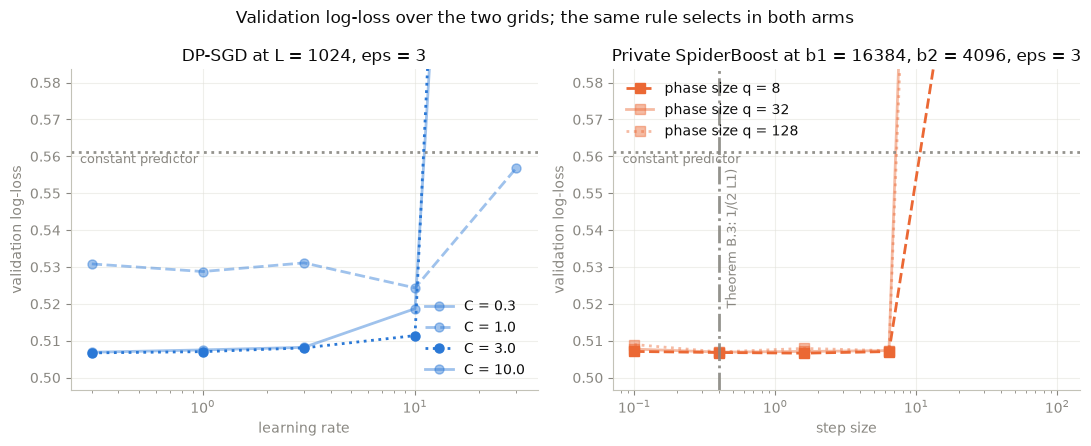

In [15]:
# What a model that ranks nothing scores. Also the natural top of the axis.
CONST_VAL_LOSS = log_loss(np.full_like(Y_VAL_NP, float(Y_VAL_NP.mean())),
                          Y_VAL_NP)
best_loss = min(r["loss"] for r in dp_sweep + sb_sweep
                if np.isfinite(r["loss"]))

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for i, clip in enumerate(DP_CLIP_GRID):
    rows = [r for r in dp_sweep
            if r["clip"] == clip and r["batch"] == BEST_DP["batch"]]
    left.plot([r["lr"] for r in rows], [r["loss"] for r in rows],
              marker=MARKER["DP-SGD"], label=f"C = {clip}",
              alpha=0.45 + 0.55 * (clip == BEST_DP["clip"]),
              color=SERIES["DP-SGD"], linestyle=["-", "--", ":"][i % 3])

for i, interval in enumerate(SB_ANCHOR_INTERVAL_GRID):
    rows = [r for r in sb_sweep
            if r["interval"] == interval and r["b1"] == BEST_SB["b1"]
            and r["b2"] == BEST_SB["b2"]]
    right.plot([r["step_size"] for r in rows], [r["loss"] for r in rows],
               marker=MARKER["Private SpiderBoost"],
               label=f"phase size q = {interval}",
               alpha=0.45 + 0.55 * (interval == BEST_SB["interval"]),
               color=SERIES["Private SpiderBoost"],
               linestyle=["--", "-", ":"][i % 3])

right.axvline(PAPER_STEP_SIZE, color=MUTED, linestyle="-.", alpha=0.9)
right.annotate("Theorem B.3: 1/(2 L1)", xy=(PAPER_STEP_SIZE, CONST_VAL_LOSS),
               xytext=(4, -12), textcoords="offset points", color=MUTED,
               fontsize=9, rotation=90, va="top")

for axis, title, xlabel in (
        (left, f"DP-SGD at L = {BEST_DP['batch']}, "
               f"eps = {TARGET_EPSILON:g}", "learning rate"),
        (right, f"Private SpiderBoost at b1 = {BEST_SB['b1']}, "
                f"b2 = {BEST_SB['b2']}, eps = {TARGET_EPSILON:g}",
         "step size")):
    axis.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
    axis.text(0.02, CONST_VAL_LOSS, "constant predictor", color=MUTED,
              fontsize=9, va="top", transform=axis.get_yaxis_transform())
    axis.set_xscale("log")
    axis.set_ylim(best_loss - 0.01, CONST_VAL_LOSS * 1.04)
    axis.set_xlabel(xlabel)
    axis.set_ylabel("validation log-loss")
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle("Validation log-loss over the two grids; the same rule selects "
             "in both arms", color=INK)
fig.tight_layout()
plt.show()

## 5. The reported models, and the output rule

Each arm's selected configuration is now run once at the full step budget,
from the shared initialization, and those two models are what every number
below is read off.

**Private SpiderBoost returns two iterates and they are not interchangeable.**
Algorithm 2's line 18 returns `w̄`, drawn uniformly from `{w_1, …, w_{T}}` —
every iterate at which a gradient estimate was released — and that is the
iterate the convergence theorem bounds. The last iterate is the one point of
the run at which no estimate was ever taken, so the proof's final inequality
has nothing to say about it. Both are shown here, once, so the gap is visible;
**everything after this cell reports the output-rule iterate**, and the sweep
above already selected on it.

One consequence to carry into the last section: the output rule is *random*,
so two runs of the same configuration differ in which iterate they return as
well as in their sampling and noise. That is run-to-run variance DP-SGD does
not have, and the seed repeats are where it shows.

In [16]:
REPORT_SEED_DP = 0
REPORT_SEED_SB = SB_SEED_OFFSET

FINAL = {}

t0 = time.time()
FINAL["DP-SGD"] = fit_dp_sgd(
    learning_rate=BEST_DP["lr"], expected_batch_size=BEST_DP["batch"],
    clip_norm=BEST_DP["clip"], noise_multiplier=SIGMA[BEST_DP["batch"]],
    steps=STEPS, seed_index=REPORT_SEED_DP)
dp_seconds = time.time() - t0

t0 = time.time()
SB_OUTPUT_RULE, SB_LAST_ITERATE = fit_spiderboost(
    step_size=BEST_SB["step_size"], anchor_interval=BEST_SB["interval"],
    b1=BEST_SB["b1"], b2=BEST_SB["b2"], scales=BEST_SB_SCALES,
    steps=STEPS, seed_index=REPORT_SEED_SB)
sb_seconds = time.time() - t0
FINAL["Private SpiderBoost"] = SB_OUTPUT_RULE

print(f"DP-SGD              {STEPS:,} steps in {dp_seconds:6.1f}s")
print(f"Private SpiderBoost {STEPS:,} steps in {sb_seconds:6.1f}s "
      f"({sb_seconds / dp_seconds:.2f}x)")
print()

out = evaluate_at(SB_OUTPUT_RULE, X_VAL, Y_VAL)
last = evaluate_at(SB_LAST_ITERATE, X_VAL, Y_VAL)
print("Private SpiderBoost, the two iterates on validation:")
print(f"  {'':<34}{'log-loss':>10}{'PR-AUC':>9}{'ECE':>9}")
print(f"  {'output rule (w-bar, reported)':<34}{out.loss:10.4f}"
      f"{out.pr_auc:9.4f}{out.ece:9.4f}")
print(f"  {'last iterate (no bound covers it)':<34}{last.loss:10.4f}"
      f"{last.pr_auc:9.4f}{last.ece:9.4f}")
print(f"\n  gap (last - output rule): log-loss "
      f"{last.loss - out.loss:+.4f}, PR-AUC {last.pr_auc - out.pr_auc:+.4f}")
print("\nEverything below reports the output-rule iterate.")

DP-SGD              10,000 steps in   69.8s
Private SpiderBoost 10,000 steps in   74.5s (1.07x)

Private SpiderBoost, the two iterates on validation:
                                      log-loss   PR-AUC      ECE
  output rule (w-bar, reported)         0.5067   0.4465   0.0081
  last iterate (no bound covers it)     0.5067   0.4471   0.0071

  gap (last - output rule): log-loss -0.0000, PR-AUC +0.0006

Everything below reports the output-rule iterate.


## 6. The trajectory, built the same way on both arms

**Notebook 02's chunked curve does not port, and is not used here.** It called
`train` in 40 chunks of 250 steps and threaded the parameters and the streams
through. The private loop cannot be resumed that way: it returns no optimizer
state and no estimator state, and the running gradient estimate, the phase
position and the noise key would all be lost between chunks — so a chunked
Private SpiderBoost run restarts the estimator every chunk and is a *different
mechanism*, not the same run observed more often.

So both curves are built the same way: **independent runs at increasing step
counts, from the same seed, with the noise scales held at the full-run
calibration.** That keeps how the curve was made from becoming a third
difference between the arms, at the cost of one run per point.

**What that costs in accounting terms, stated rather than hidden:** each
intermediate point runs fewer releases than the calibration assumed, so a
prefix of this schedule spends *less* than the budget. The intermediate points
are therefore **conservative** — each is a model that could have been released
at a smaller ε than the one printed — rather than mis-accounted. Only the
final point, at the full step count, is a run whose ε is the ε section 3
calibrated.

Both curves are read on the same two fixed evaluation sets: a fixed
100,000-row subsample of the training rows, so the curve shows the objective
being descended, and the full 100,000-row validation split, so it shows
whether that descent generalises. Same sets, same losses, both arms. The
Private SpiderBoost point at each step count is its output-rule iterate.

In [17]:
# A fixed subsample of the training rows, drawn once, used by both arms.
curve_index = jnp.asarray(
    np.random.default_rng(BASE_SEED + 1).choice(n_train, 100_000,
                                                replace=False))
X_CURVE, Y_CURVE = X_TRAIN[curve_index], Y_TRAIN[curve_index]


def curve_point(params):
    # The four numbers recorded at one step count.
    train = evaluate_at(params, X_CURVE, Y_CURVE)
    val = evaluate_at(params, X_VAL, Y_VAL)
    return train.loss, val.loss, val.pr_auc, val.ece


# Step 0 is the shared initialization rather than a run: both arms start
# there, so it is the one point the two curves have in common by
# construction.
start = (0,) + curve_point(fresh_params())
CURVE = {arm: [start] for arm in ARMS}

t0 = time.time()
for steps in TRAJECTORY_STEPS:
    if steps == STEPS:
        params_dp = FINAL["DP-SGD"]           # the run from section 5
    else:
        params_dp = fit_dp_sgd(
            learning_rate=BEST_DP["lr"], expected_batch_size=BEST_DP["batch"],
            clip_norm=BEST_DP["clip"], noise_multiplier=SIGMA[BEST_DP["batch"]],
            steps=steps, seed_index=REPORT_SEED_DP)
    CURVE["DP-SGD"].append((steps,) + curve_point(params_dp))

    if steps == STEPS:
        params_sb = FINAL["Private SpiderBoost"]
    else:
        params_sb, _ = fit_spiderboost(
            step_size=BEST_SB["step_size"], anchor_interval=BEST_SB["interval"],
            b1=BEST_SB["b1"], b2=BEST_SB["b2"], scales=BEST_SB_SCALES,
            steps=steps, seed_index=REPORT_SEED_SB)
    CURVE["Private SpiderBoost"].append((steps,) + curve_point(params_sb))

    print(f"  {steps:>6,} steps   "
          f"DP-SGD val {CURVE['DP-SGD'][-1][2]:.4f}   "
          f"SpiderBoost val {CURVE['Private SpiderBoost'][-1][2]:.4f}")
print(f"\ntrajectory: {2 * (len(TRAJECTORY_STEPS) - 1)} extra independent "
      f"runs in {time.time() - t0:.0f}s "
      f"(the point at {STEPS:,} steps reuses section 5's run)")

     250 steps   DP-SGD val 0.5105   SpiderBoost val 0.5080


     500 steps   DP-SGD val 0.5089   SpiderBoost val 0.5074


   1,000 steps   DP-SGD val 0.5079   SpiderBoost val 0.5070


   2,500 steps   DP-SGD val 0.5071   SpiderBoost val 0.5068


   5,000 steps   DP-SGD val 0.5069   SpiderBoost val 0.5067
  10,000 steps   DP-SGD val 0.5068   SpiderBoost val 0.5067

trajectory: 10 extra independent runs in 144s (the point at 10,000 steps reuses section 5's run)


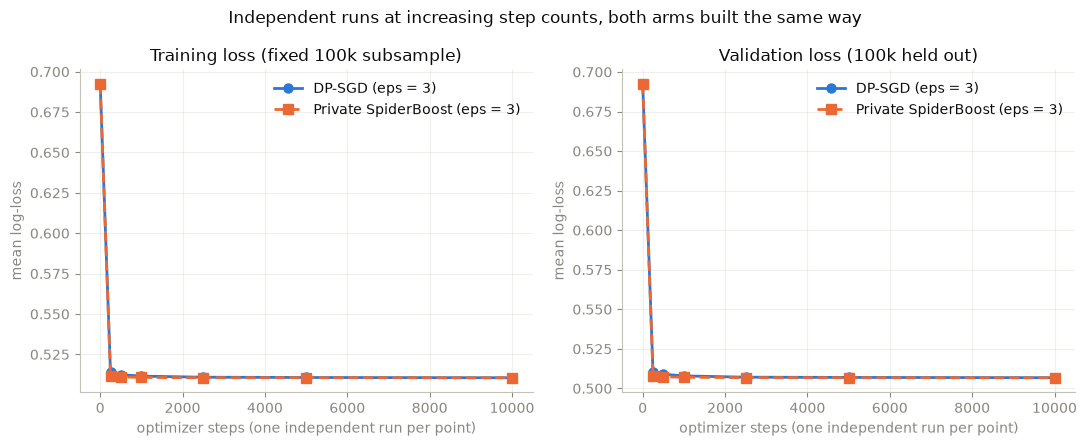

In [18]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for arm in ARMS:
    steps_axis = [p[0] for p in CURVE[arm]]
    label = f"{arm} (eps = {TARGET_EPSILON:g})"
    left.plot(steps_axis, [p[1] for p in CURVE[arm]], color=SERIES[arm],
              linestyle=DASH[arm], marker=MARKER[arm], label=label)
    right.plot(steps_axis, [p[2] for p in CURVE[arm]], color=SERIES[arm],
               linestyle=DASH[arm], marker=MARKER[arm], label=label)

for axis, title in (
        (left, "Training loss (fixed 100k subsample)"),
        (right, "Validation loss (100k held out)")):
    axis.set_xlabel("optimizer steps (one independent run per point)")
    axis.set_ylabel("mean log-loss")
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle("Independent runs at increasing step counts, both arms built the "
             "same way", color=INK)
fig.tight_layout()
plt.show()

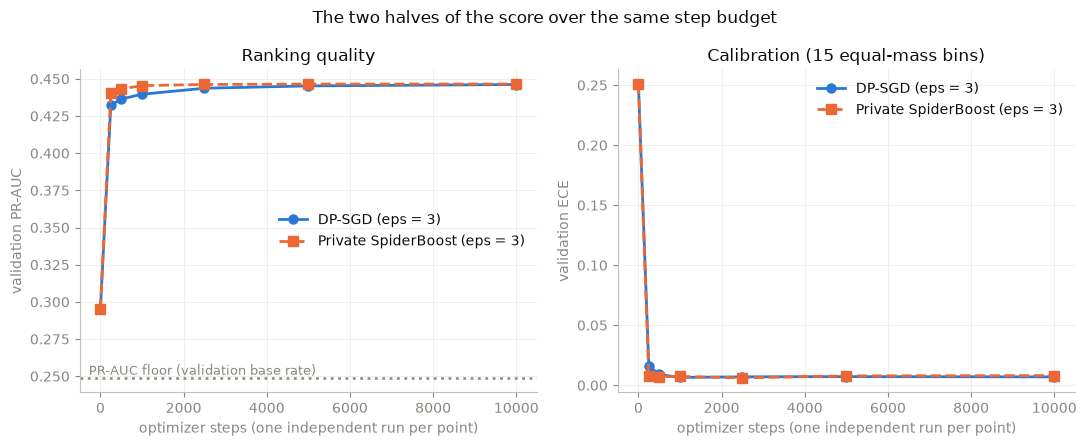

In [19]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for arm in ARMS:
    steps_axis = [p[0] for p in CURVE[arm]]
    label = f"{arm} (eps = {TARGET_EPSILON:g})"
    left.plot(steps_axis, [p[3] for p in CURVE[arm]], color=SERIES[arm],
              linestyle=DASH[arm], marker=MARKER[arm], label=label)
    right.plot(steps_axis, [p[4] for p in CURVE[arm]], color=SERIES[arm],
               linestyle=DASH[arm], marker=MARKER[arm], label=label)

left.axhline(VAL_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
left.text(0.02, VAL_BASE_RATE, "PR-AUC floor (validation base rate)",
          color=MUTED, fontsize=9, va="bottom",
          transform=left.get_yaxis_transform())

for axis, title, ylabel in (
        (left, "Ranking quality", "validation PR-AUC"),
        (right, f"Calibration ({N_BINS} equal-mass bins)", "validation ECE")):
    axis.set_xlabel("optimizer steps (one independent run per point)")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle("The two halves of the score over the same step budget",
             color=INK)
fig.tight_layout()
plt.show()

## 7. The operating point, then the test split

A confusion matrix and a TPR are quantities at a threshold, and a threshold is
a choice. Made carelessly it becomes a third difference between the arms, so
it is made by **one rule applied identically to both models: the threshold
that maximises F1 on the validation split** (`best_f1_threshold`, which takes
every observed score as a candidate and so finds the exact maximiser rather
than approximating it).

The threshold is chosen **per model**, on validation, and frozen before the
test split is read. Choosing it on test would make every number after it a
fitted quantity; forcing one shared threshold on both models would penalise
whichever is differently scaled, which is not the same thing as being worse.
The rule is shared; the number it returns is each model's own. Which split it
was chosen on is the caller's to state, and this cell is that statement
(ADR-0016).

In [20]:
THRESHOLD, VAL_F1 = {}, {}
for arm in ARMS:
    probs = probabilities(scores(FINAL[arm], X_VAL))
    point = best_f1_threshold(probs, Y_VAL_NP)
    THRESHOLD[arm], VAL_F1[arm] = point.threshold, point.f1
    print(f"{arm:<22} validation-optimal threshold p >= "
          f"{THRESHOLD[arm]:.4f}   val F1 = {VAL_F1[arm]:.4f}")
print("\nchosen on validation, frozen here, before the test split is read.")

DP-SGD                 validation-optimal threshold p >= 0.2368   val F1 = 0.4915
Private SpiderBoost    validation-optimal threshold p >= 0.2344   val F1 = 0.4912

chosen on validation, frozen here, before the test split is read.


Now, and only now, the test split.

In [21]:
# The first read of the test split in this notebook. The threshold above
# is already frozen.
Y_TEST_NP = np.asarray(Y_TEST, dtype=np.float64)
base_rate = float(Y_TEST_NP.mean())
print(f"test split: {len(Y_TEST_NP):,} rows, base rate {base_rate:.4f} "
      f"(the PR-AUC floor below)\n")
TEST = {}

for arm in ARMS:
    probs = probabilities(scores(FINAL[arm], X_TEST))
    curve = pr_curve(probs, Y_TEST_NP)
    counts = confusion_at(probs, Y_TEST_NP, THRESHOLD[arm])
    tn, fp, fn, tp = counts
    TEST[arm] = dict(
        probs=probs, precision_curve=curve.precision,
        recall_curve=curve.recall, pr_auc=curve.average_precision,
        loss=log_loss(probs, Y_TEST_NP),
        ne=normalized_entropy(probs, Y_TEST_NP),
        ece=expected_calibration_error(probs, Y_TEST_NP, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, Y_TEST_NP), confusion=counts,
        tpr=tp / (tp + fn),
        precision_at=tp / (tp + fp) if tp + fp else float("nan"),
    )

# The threshold-free scores first: these are properties of the model.
CONST = np.full_like(Y_TEST_NP, base_rate)
print(f"{'':<22}{'log-loss':>10}{'NE':>8}{'ECE':>8}{'cal-ratio':>11}"
      f"{'PR-AUC':>9}")
print(f"{'constant predictor':<22}{log_loss(CONST, Y_TEST_NP):10.4f}"
      f"{normalized_entropy(CONST, Y_TEST_NP):8.4f}"
      f"{expected_calibration_error(CONST, Y_TEST_NP, n_bins=N_BINS):8.4f}"
      f"{calibration_ratio(CONST, Y_TEST_NP):11.4f}{base_rate:9.4f}")
for arm in ARMS:
    r = TEST[arm]
    print(f"{arm:<22}{r['loss']:10.4f}{r['ne']:8.4f}{r['ece']:8.4f}"
          f"{r['cal_ratio']:11.4f}{r['pr_auc']:9.4f}")

# Then the operating point, which is a choice rather than a property.
print(f"\n{'':<22}{'TPR':>9}{'precision':>11}{'F1':>8}{'threshold':>11}")
for arm in ARMS:
    r = TEST[arm]
    f1 = 2 * r["precision_at"] * r["tpr"] / (r["precision_at"] + r["tpr"])
    print(f"{arm:<22}{r['tpr']:9.4f}{r['precision_at']:11.4f}{f1:8.4f}"
          f"{THRESHOLD[arm]:11.4f}")

print(f"\nBoth arms at epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"{ACCOUNTANT.upper()} accounting, over {STEPS:,} steps.")
print("DP-SGD's sensitivity is enforced by the clip to C; Private "
      "SpiderBoost's is assumed (ADR-0009), on the R printed in section 1.")

test split: 200,000 rows, base rate 0.2520 (the PR-AUC floor below)



                        log-loss      NE     ECE  cal-ratio   PR-AUC
constant predictor        0.5645  1.0000  0.0000     1.0000   0.2520
DP-SGD                    0.5123  0.9076  0.0041     1.0054   0.4462
Private SpiderBoost       0.5123  0.9074  0.0038     1.0085   0.4466

                            TPR  precision      F1  threshold
DP-SGD                   0.6816     0.3810  0.4888     0.2368
Private SpiderBoost      0.6813     0.3810  0.4887     0.2344

Both arms at epsilon = 3, delta = 1e-06, RDP accounting, over 10,000 steps.
DP-SGD's sensitivity is enforced by the clip to C; Private SpiderBoost's is assumed (ADR-0009), on the R printed in section 1.


In [22]:
for arm in ARMS:
    show_confusion(TEST[arm]["confusion"], f"{arm} on the test split",
                   THRESHOLD[arm])
    print()

DP-SGD on the test split
                 predicted no    predicted click
  actual no            93,780             55,820
  actual click         16,045             34,355
  precision 0.3810   TPR (recall) 0.6816   (at threshold p >= 0.2368)

Private SpiderBoost on the test split
                 predicted no    predicted click
  actual no            93,815             55,785
  actual click         16,063             34,337
  precision 0.3810   TPR (recall) 0.6813   (at threshold p >= 0.2344)



The precision–recall curves on one axes, with PR-AUC in the legend, the base
rate as the floor a random ranking reaches, and each model's chosen operating
point marked. The curve is the model's behaviour across every threshold; the
marker is the one point the confusion matrices above report.

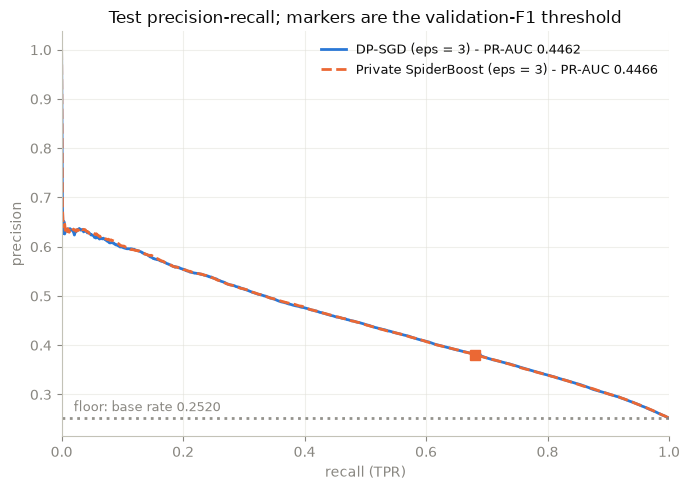

In [23]:
fig, axis = plt.subplots(figsize=(7, 5))

for arm in ARMS:
    r = TEST[arm]
    stride = max(1, len(r["recall_curve"]) // 2000)
    axis.plot(r["recall_curve"][::stride], r["precision_curve"][::stride],
              color=SERIES[arm], linestyle=DASH[arm],
              label=f"{arm} (eps = {TARGET_EPSILON:g}) - "
                    f"PR-AUC {r['pr_auc']:.4f}")
    axis.plot([r["tpr"]], [r["precision_at"]], marker=MARKER[arm],
              color=SERIES[arm], linestyle="none")

axis.axhline(base_rate, color=MUTED, linestyle=":", alpha=0.9)
axis.annotate(f"floor: base rate {base_rate:.4f}", xy=(0.02, base_rate),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
axis.set_xlabel("recall (TPR)")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_title("Test precision-recall; markers are the validation-F1 threshold")
axis.legend(loc="upper right", fontsize=9)
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

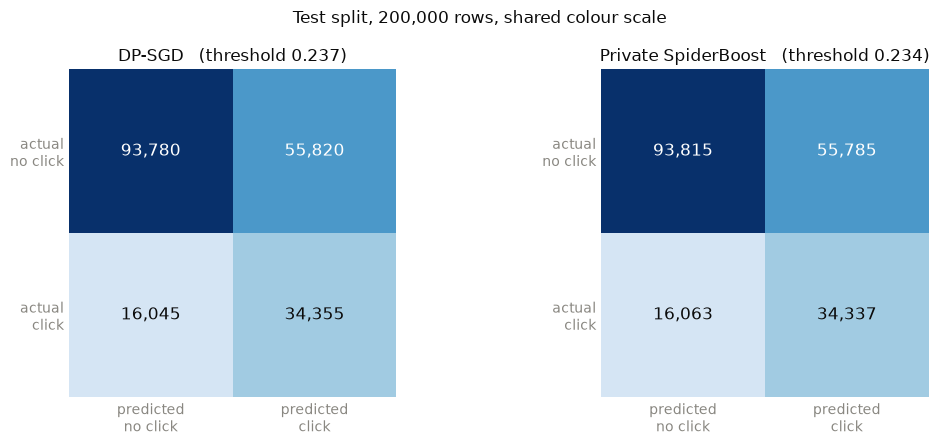

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["no click", "click"]
shared_max = max(max(TEST[arm]["confusion"]) for arm in ARMS)

for axis, arm in zip(axes, ARMS):
    tn, fp, fn, tp = TEST[arm]["confusion"]
    grid = np.array([[tn, fp], [fn, tp]])
    axis.imshow(grid, cmap="Blues", vmin=0, vmax=shared_max)
    for i in range(2):
        for j in range(2):
            axis.text(j, i, f"{grid[i, j]:,}", ha="center", va="center",
                      fontsize=12,
                      color="white" if grid[i, j] > shared_max * 0.55 else INK)
    axis.set_xticks([0, 1], [f"predicted\n{lab}" for lab in labels])
    axis.set_yticks([0, 1], [f"actual\n{lab}" for lab in labels])
    axis.set_title(f"{arm}   (threshold {THRESHOLD[arm]:.3f})")
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.tick_params(length=0)
    axis.grid(False)

fig.suptitle(f"Test split, {len(Y_TEST_NP):,} rows, shared colour scale",
             color=INK)
fig.tight_layout()
plt.show()

### Calibration, measured rather than inferred

Everything above is either a ranking read or a quantity at a threshold. The
two below are neither. The reliability curve asks whether each arm's
probabilities are the rates that occurred, and the decomposition splits the
log-loss into the half a ranking metric can see and the half it cannot:
`log-loss = calibration − resolution + uncertainty + residual`, at the same 15
equal-mass bins. `uncertainty` is a property of the test labels and is
identical across the arms by construction, so any gap sits in the other three.

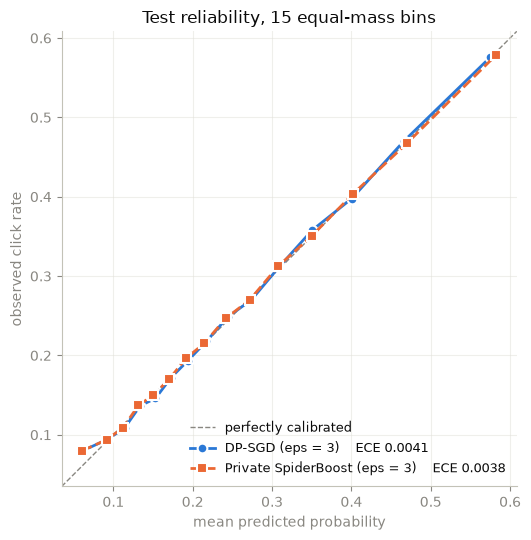

DP-SGD                 15 bins kept, 13,333-13,334 records each, largest gap -0.0180 (predicted - observed)
Private SpiderBoost    15 bins kept, 13,333-13,334 records each, largest gap -0.0191 (predicted - observed)


In [25]:
RELIABILITY = {arm: reliability_curve(TEST[arm]["probs"], Y_TEST_NP,
                                      n_bins=N_BINS) for arm in ARMS}

points = np.concatenate([np.concatenate([c.mean_predicted, c.mean_observed])
                         for c in RELIABILITY.values()])
pad = 0.05 * (points.max() - points.min())
lo, hi = points.min() - pad, points.max() + pad

fig, axis = plt.subplots(figsize=(5.5, 5.5))
axis.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color=MUTED,
          zorder=1, label="perfectly calibrated")

for arm in ARMS:
    curve = RELIABILITY[arm]
    axis.plot(curve.mean_predicted, curve.mean_observed, marker=MARKER[arm],
              markersize=7, linewidth=2, color=SERIES[arm], zorder=2,
              linestyle=DASH[arm], markeredgecolor="white",
              markeredgewidth=1.5,
              label=f"{arm} (eps = {TARGET_EPSILON:g})    "
                    f"ECE {TEST[arm]['ece']:.4f}")

axis.set_xlim(lo, hi)
axis.set_ylim(lo, hi)
axis.set_aspect("equal")
axis.set_xlabel("mean predicted probability")
axis.set_ylabel("observed click rate")
axis.set_title(f"Test reliability, {N_BINS} equal-mass bins", color=INK)
axis.grid(alpha=0.5)
axis.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

for arm in ARMS:
    curve = RELIABILITY[arm]
    worst = curve.gap[int(np.argmax(np.abs(curve.gap)))]
    print(f"{arm:<22} {len(curve.count)} bins kept, "
          f"{curve.count.min():,}-{curve.count.max():,} records each, "
          f"largest gap {worst:+.4f} (predicted - observed)")

In [26]:
DECOMPOSITION = {arm: log_loss_decomposition(TEST[arm]["probs"], Y_TEST_NP,
                                             n_bins=N_BINS) for arm in ARMS}

print(f"{'':<22}{'calibration':>13}{'resolution':>12}{'uncertainty':>13}"
      f"{'residual':>10}{'log-loss':>10}")
for arm in ARMS:
    d = DECOMPOSITION[arm]
    print(f"{arm:<22}{d.calibration:13.4f}{d.resolution:12.4f}"
          f"{d.uncertainty:13.4f}{d.residual:10.4f}{d.total:10.4f}")

dp, sb = DECOMPOSITION["DP-SGD"], DECOMPOSITION["Private SpiderBoost"]
print(f"\nPrivate SpiderBoost - DP-SGD")
print(f"  calibration {sb.calibration - dp.calibration:+.4f}   "
      f"resolution {sb.resolution - dp.resolution:+.4f}   "
      f"residual {sb.residual - dp.residual:+.4f}   "
      f"->  log-loss {sb.total - dp.total:+.4f}")

                        calibration  resolution  uncertainty  residual  log-loss
DP-SGD                       0.0002      0.0521       0.5645   -0.0003    0.5123
Private SpiderBoost          0.0002      0.0522       0.5645   -0.0003    0.5123

Private SpiderBoost - DP-SGD
  calibration +0.0000   resolution +0.0001   residual +0.0000   ->  log-loss -0.0001


## 8. Does the difference survive a change of seed?

The selected configuration of each arm is re-run at three seeds. The
initialization stays `jax.random.key(INIT_SEED)`; what changes is the sampling
stream and the noise stream. Three seeds is a spread, not a confidence
interval, and it is reported as min/max.

**The two arms do not have the same sources of run-to-run variance.** DP-SGD's
are the Poisson draws and the Gaussian noise. Private SpiderBoost has those
and, on top of them, the **random output rule**: each run returns a uniformly
drawn iterate from its own trajectory, so two runs differ in *which* model they
return as well as in how it was trained. A wider spread on the private arm is
that rule showing up, not instability in the optimizer.

In [27]:
REPEATS = {}

t0 = time.time()
for arm in ARMS:
    values = []
    for seed in SEEDS:
        if arm == "DP-SGD":
            params = fit_dp_sgd(
                learning_rate=BEST_DP["lr"],
                expected_batch_size=BEST_DP["batch"],
                clip_norm=BEST_DP["clip"],
                noise_multiplier=SIGMA[BEST_DP["batch"]],
                steps=STEPS, seed_index=1000 + seed)
        else:
            params, _ = fit_spiderboost(
                step_size=BEST_SB["step_size"],
                anchor_interval=BEST_SB["interval"], b1=BEST_SB["b1"],
                b2=BEST_SB["b2"], scales=BEST_SB_SCALES,
                steps=STEPS, seed_index=SB_SEED_OFFSET + 1000 + seed)
        values.append(evaluate_at(params, X_TEST, Y_TEST))
    REPEATS[arm] = values
    losses = [v.loss for v in values]
    prs = [v.pr_auc for v in values]
    eces = [v.ece for v in values]
    print(f"{arm:<22} test log-loss {np.mean(losses):.4f} "
          f"[{min(losses):.4f}, {max(losses):.4f}]   "
          f"PR-AUC {np.mean(prs):.4f} [{min(prs):.4f}, {max(prs):.4f}]   "
          f"ECE {np.mean(eces):.4f} [{min(eces):.4f}, {max(eces):.4f}]")
    print(f"{'':<22}(the reported run: {TEST[arm]['loss']:.4f} / "
          f"{TEST[arm]['pr_auc']:.4f} / {TEST[arm]['ece']:.4f})")


def gap_of(field):
    # DP-SGD minus Private SpiderBoost: at the means, and at the extremes.
    a = [getattr(v, field) for v in REPEATS["DP-SGD"]]
    b = [getattr(v, field) for v in REPEATS["Private SpiderBoost"]]
    return (float(np.mean(a)) - float(np.mean(b)),
            min(a) - max(b), max(a) - min(b))


print()
for field, name in (("pr_auc", "PR-AUC"), ("loss", "log-loss"),
                    ("ece", "ECE")):
    mean_gap, low, high = gap_of(field)
    print(f"{name:>9} gap (DP-SGD - Private SpiderBoost): mean "
          f"{mean_gap:+.4f}, range [{low:+.4f}, {high:+.4f}] over "
          f"{len(SEEDS)} seeds")
print(f"\n({time.time() - t0:.0f}s)")

DP-SGD                 test log-loss 0.5123 [0.5123, 0.5124]   PR-AUC 0.4462 [0.4461, 0.4464]   ECE 0.0036 [0.0034, 0.0038]
                      (the reported run: 0.5123 / 0.4462 / 0.0041)


Private SpiderBoost    test log-loss 0.5124 [0.5123, 0.5126]   PR-AUC 0.4462 [0.4452, 0.4468]   ECE 0.0045 [0.0033, 0.0060]
                      (the reported run: 0.5123 / 0.4466 / 0.0038)

   PR-AUC gap (DP-SGD - Private SpiderBoost): mean +0.0001, range [-0.0008, +0.0013] over 3 seeds
 log-loss gap (DP-SGD - Private SpiderBoost): mean -0.0001, range [-0.0003, +0.0001] over 3 seeds
      ECE gap (DP-SGD - Private SpiderBoost): mean -0.0009, range [-0.0026, +0.0005] over 3 seeds

(434s)


## What this shows, and what it does not

> **Placeholder: this section has not yet been written against the run above.**
> The figures and tables in this file are the full run; this closing section
> is not yet read off them and quotes no number from them. It is written last,
> against the run that is committed, so that the prose cannot outlive the
> figures — which is the trap notebook 02 fell into and is flagged for.

What is already true of the *method*, and stays true whatever the numbers say:

**The comparison.** Both arms descend the same per-sample BCE on the same
700,000 rows, from the same initialization, with the same optimizer, at the
same `R = 2.0` and the same step budget, each at its own configuration chosen
by the same rule — lowest validation log-loss — on the same 100,000-row
validation split. Both are calibrated to ε = 3 at δ = 1e-6 by RDP over exactly
the steps that ran, and both report ε back from the scales the loops were
handed.

**The two epsilons are comparable quantities and not comparable guarantees.**
DP-SGD's sensitivity is enforced by the per-sample clip; Private SpiderBoost's
is assumed (ADR-0009) and rests entirely on the enforced feature-norm bound
`R`, which fixes `L0`, `L1` and every noise scale (ADR-0012). Nothing in dimma
checks that assumption, and a supplied constant the data exceeds produces a
false ε silently.

**Two caveats travel with any result here.** The preprocessing statistics are
fitted on the training split and accounted for in no budget (ADR-0008); and
the hyperparameter search is unaccounted, so the reported ε covers only the
selected run in each arm.

**Where the two arms are not compared like for like, by construction:** the
private arm's reported model is a *randomly drawn* iterate, so it carries
variance DP-SGD's last iterate does not, and its intermediate trajectory
points are conservative rather than exact — a prefix of the schedule spends
less than the budget it was calibrated for.

Not shown and not claimed: one budget only (ε = 3), one dataset, one model,
one loss; three seeds is a spread and not an interval; and PLD would price
both arms lower than RDP does (ADR-0011), held fixed here because the choice
has to cancel across the arms.